# 03. Transformer Block

**Topics covered:** LayerNorm · Residual Connections · Feed-Forward Network · Transformer Block

This notebook builds on [01_scaled_dot_product_attention.ipynb](https://github.com/S33mi/modern-ai-llm-journey/blob/main/01_attention_transformers/01_scaled_dot_product_attention.ipynb) and [02_multi_head_attention.ipynb](https://github.com/S33mi/modern-ai-llm-journey/blob/main/01_attention_transformers/02_multi_head_attention.ipynb).

We will:
1. Understand **Layer Normalization** and why it is preferred over BatchNorm in Transformers
2. See the role of **Residual (skip) Connections**
3. Implement the **Position-wise Feed-Forward Network**
4. Assemble everything into a complete **Transformer Block** (the fundamental unit of GPT / BERT-style models)
5. Stack multiple blocks and inspect intermediate activations

## 1. Setup & Imports

In [16]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Layer Normalization

### Why LayerNorm instead of BatchNorm?

- **BatchNorm** normalizes across the batch dimension → sensitive to batch size and not well-defined at inference for variable-length sequences.
- **LayerNorm** normalizes across the **feature** dimension for each individual token → independent of batch size and sequence length. Perfect for NLP.

For a vector $\mathbf{x} \in \mathbb{R}^{d}$:

$$
\mu = \frac{1}{d}\sum_{i=1}^{d} x_i,\qquad
\sigma = \sqrt{\frac{1}{d}\sum_{i=1}^{d}(x_i-\mu)^2 + \varepsilon}
$$

$$
\text{LayerNorm}(\mathbf{x}) = \gamma \odot \frac{\mathbf{x}-\mu}{\sigma} + \beta
$$

where $\gamma$ and $\beta$ are learnable scale and shift parameters.

In [17]:
class LayerNorm(nn.Module):
    """Layer Normalization (from-scratch for learning)."""
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))   # scale
        self.beta  = nn.Parameter(torch.zeros(d_model))  # shift

    def forward(self, x):
        # x: (batch, seq, d_model)
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta


# Quick check vs PyTorch
d_model = 64
ln_ours = LayerNorm(d_model)
ln_torch = nn.LayerNorm(d_model)

# Copy parameters for fair comparison
with torch.no_grad():
    ln_torch.weight.copy_(ln_ours.gamma)
    ln_torch.bias.copy_(ln_ours.beta)

x = torch.randn(2, 10, d_model)
print("Max abs diff vs nn.LayerNorm:", (ln_ours(x) - ln_torch(x)).abs().max().item())

Max abs diff vs nn.LayerNorm: 4.76837158203125e-07


## 3. Residual Connections

A residual (skip) connection simply adds the input of a sub-layer back to its output:

$$
\mathbf{y} = \mathbf{x} + \text{SubLayer}(\mathbf{x})
$$

### Why residuals matter

- Enable training of **very deep** networks (gradient highways).
- Let the model learn identity mappings when a sub-layer is not useful.
- Stabilize training together with LayerNorm.

In the original Transformer the residual is applied **around** each sub-layer and then LayerNorm is applied (Post-LN). Many modern LLMs use **Pre-LN** (LayerNorm before the sub-layer), which is often more stable for deep models.

In [18]:
def residual_add(x, sublayer_out):
    """Simple residual connection."""
    return x + sublayer_out


# Demonstrate that residual preserves magnitude better than pure sub-layer
x = torch.randn(1, 8, 64)
sublayer = nn.Linear(64, 64)
out_no_res = sublayer(x)
out_res    = residual_add(x, sublayer(x))

print(f"Input norm:          {x.norm().item():.3f}")
print(f"Without residual:    {out_no_res.norm().item():.3f}")
print(f"With residual:       {out_res.norm().item():.3f}")

Input norm:          21.785
Without residual:    12.811
With residual:       25.057


## 4. Position-wise Feed-Forward Network (FFN)

After attention, every token is independently passed through a two-layer MLP:

$$
\text{FFN}(\mathbf{x}) = \text{Activation}(\mathbf{x} W_1 + b_1) W_2 + b_2
$$

Typical choices:

| Model family | Activation | Expansion ratio |
|--------------|------------|-----------------|
| Original Transformer | ReLU | 4× |
| GPT-2 / many modern LLMs | GELU | 4× |
| LLaMA / Mistral | SwiGLU | ~8/3 × |

We implement the classic GPT-style FFN with GELU.

In [19]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""
    def __init__(self, d_model: int, d_ff: int = None, dropout: float = 0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model          # classic 4× expansion
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq, d_model)
        x = self.fc1(x)
        x = F.gelu(x)                       # GPT-2 style
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


ffn = FeedForward(d_model=64)
x = torch.randn(2, 10, 64)
print("FFN input :", x.shape)
print("FFN output:", ffn(x).shape)

FFN input : torch.Size([2, 10, 64])
FFN output: torch.Size([2, 10, 64])


## 5. Multi-Head Attention (recap from notebook 02)

We reuse a compact version of the Multi-Head Attention module.

In [20]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        if mask.dtype == torch.bool:
            scores = scores.masked_fill(~mask, float("-inf"))
        else:
            scores = scores + mask
    attn = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        B, T, _ = x.size()
        Q = self.W_Q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        if mask is not None and mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)

        attn_out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, -1)
        out = self.W_O(attn_out)
        out = self.dropout(out)

        if return_attention:
            return out, attn_weights
        return out

## 6. The Transformer Block

There are two common variants:

### Post-LN (original paper)
```
x = x + Attention(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```

### Pre-LN (most modern LLMs – GPT-2, LLaMA, …)
```
x = x + Attention(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```
(The difference is mainly *when* the residual is added relative to the norm; Pre-LN is usually more stable for deep stacks.)

We implement the **Pre-LN** version that dominates current practice.

In [21]:
class TransformerBlock(nn.Module):
    """
    Pre-LN Transformer Block (GPT-style).

    Architecture:
        x → LayerNorm → Multi-Head Attention → residual add
          → LayerNorm → Feed-Forward          → residual add
    """
    def __init__(self, d_model: int, n_heads: int, d_ff: int = None, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, mask=None, return_attention=False):
        # Pre-LN + residual around attention
        if return_attention:
            attn_out, attn_weights = self.attn(self.ln1(x), mask=mask, return_attention=True)
            x = x + attn_out
            x = x + self.ffn(self.ln2(x))
            return x, attn_weights
        else:
            x = x + self.attn(self.ln1(x), mask=mask)
            x = x + self.ffn(self.ln2(x))
            return x

In [22]:
# Sanity check
d_model = 64
n_heads = 8
seq_len = 16
batch_size = 2

block = TransformerBlock(d_model, n_heads).to(device)
x = torch.randn(batch_size, seq_len, d_model, device=device)

# Causal mask
mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))

out, attn = block(x, mask=mask, return_attention=True)
print("Input shape :", x.shape)
print("Output shape:", out.shape)
print("Attention   :", attn.shape)   # (B, n_heads, T, T)

Input shape : torch.Size([2, 16, 64])
Output shape: torch.Size([2, 16, 64])
Attention   : torch.Size([2, 8, 16, 16])


## 7. Stacking Multiple Blocks

A full Transformer encoder / decoder body is simply a stack of identical blocks.

In [23]:
class TransformerStack(nn.Module):
    """Stack of N Transformer blocks + final LayerNorm."""
    def __init__(self, n_layers: int, d_model: int, n_heads: int, d_ff: int = None, dropout: float = 0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)   # final norm (common in GPT)

    def forward(self, x, mask=None):
        for block in self.blocks:
            x = block(x, mask=mask)
        return self.ln_f(x)


stack = TransformerStack(n_layers=4, d_model=64, n_heads=8).to(device)
x = torch.randn(2, 20, 64, device=device)
mask = torch.tril(torch.ones(20, 20, dtype=torch.bool, device=device))

out = stack(x, mask=mask)
print("Stack output shape:", out.shape)
print("Number of parameters:", sum(p.numel() for p in stack.parameters()))

Stack output shape: torch.Size([2, 20, 64])
Number of parameters: 199040


## 8. Visualizing Residual Stream Magnitude

A useful diagnostic is to track the L2 norm of the residual stream as it flows through the blocks.

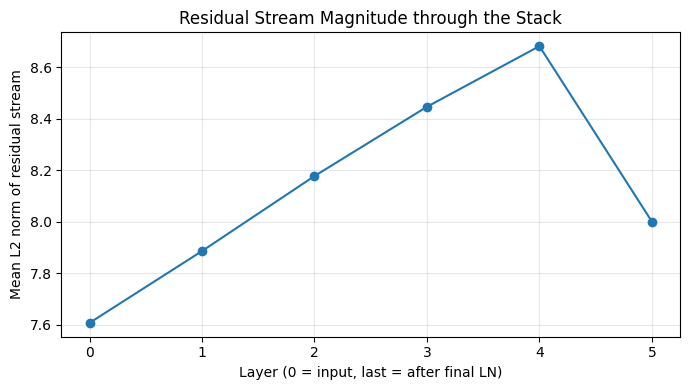

Norms: [7.606, 7.885, 8.177, 8.446, 8.681, 8.0]


In [24]:
def track_residual_norms(model, x, mask=None):
    """Record residual-stream norm after each block."""
    norms = [x.norm(dim=-1).mean().item()]
    with torch.no_grad():
        for block in model.blocks:
            x = block(x, mask=mask)
            norms.append(x.norm(dim=-1).mean().item())
        x = model.ln_f(x)
        norms.append(x.norm(dim=-1).mean().item())
    return norms


norms = track_residual_norms(stack, torch.randn(1, 16, 64, device=device), mask[:16, :16])

plt.figure(figsize=(7, 4))
plt.plot(range(len(norms)), norms, marker="o")
plt.xlabel("Layer (0 = input, last = after final LN)")
plt.ylabel("Mean L2 norm of residual stream")
plt.title("Residual Stream Magnitude through the Stack")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Norms:", [round(n, 3) for n in norms])

## 9. Complete Minimal Example

Putting a single block through a short causal sequence.

In [25]:
torch.manual_seed(7)

d_model, n_heads, seq_len = 32, 4, 8
block = TransformerBlock(d_model, n_heads, dropout=0.0).to(device)

x = torch.randn(1, seq_len, d_model, device=device)
mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))

out, attn = block(x, mask=mask, return_attention=True)

print("Output shape:", out.shape)
print("\nAttention weights of head 0 (causal):")
print(attn[0, 0].detach().cpu().numpy().round(3))

Output shape: torch.Size([1, 8, 32])

Attention weights of head 0 (causal):
[[1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.576 0.424 0.    0.    0.    0.    0.    0.   ]
 [0.3   0.351 0.349 0.    0.    0.    0.    0.   ]
 [0.269 0.271 0.23  0.23  0.    0.    0.    0.   ]
 [0.145 0.157 0.22  0.224 0.255 0.    0.    0.   ]
 [0.249 0.155 0.165 0.115 0.131 0.184 0.    0.   ]
 [0.144 0.166 0.15  0.189 0.062 0.048 0.241 0.   ]
 [0.157 0.139 0.118 0.143 0.104 0.107 0.132 0.1  ]]


## 10. Summary

| Component | Role |
|-----------|------|
| **LayerNorm** | Stabilizes activations per token; preferred over BatchNorm for sequences |
| **Residual Connection** | Provides gradient highways and allows identity mappings |
| **Feed-Forward Network** | Position-wise non-linear transformation (usually 4× expansion + GELU) |
| **Transformer Block** | Attention + FFN wrapped with Pre-LN + residuals — the basic building block of modern LLMs |

### Architecture at a glance (Pre-LN)

```
x ──► LayerNorm ──► Multi-Head Attention ──► +
 │                                           │
 └───────────────────────────────────────────┘
x ──► LayerNorm ──► Feed-Forward ───────────► +
 │                                           │
 └───────────────────────────────────────────┘
```

### Key take-aways

- Pre-LN + residual is the dominant design in GPT-2/3, LLaMA, Mistral, etc.
- The FFN usually contains the majority of the parameters of a block.
- Stacking identical blocks + a final LayerNorm gives the Transformer body.

---

**Next notebook:** [`04_tiny_gpt_from_scratch.ipynb`](https://github.com/S33mi/modern-ai-llm-journey/blob/main/01_attention_transformers/04_tiny_gpt_from_scratch.ipynb)  
Full GPT Architecture · Positional Encoding · Causal Language Modeling